In [1]:
import torch
import os
import json
import sys
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "0"
sys.path.append("../representation_collection")
sys.path.append("../sae_trainer")
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_IM_START_TOKEN, DEFAULT_IM_END_TOKEN
from llava.conversation import conv_templates, SeparatorStyle
from llava.model.builder import load_pretrained_model
from llava.utils import disable_torch_init
from llava.mm_utils import tokenizer_image_token, get_model_name_from_path, KeywordsStoppingCriteria
from hooks import InputHook

from sae_model import VL_SAE, AuxiliaryAE
from utils import display_concepts

from PIL import Image
import matplotlib.pyplot as plt

### Loading Pre-trained Model 

In [9]:
# LVLM
model_path = "../pretrained_models/llava-v1.5-7b"
extract_layers = 'model.layers.30'
sae_path = '../sae_trainer/sae_weights/llava_256_8_best.pth'
alignment_path = '../sae_trainer/sae_weights/llava_aux_best.pt'

disable_torch_init()
model_path = os.path.expanduser(model_path)
model_name = get_model_name_from_path(model_path)
tokenizer, model, image_processor, context_len = load_pretrained_model(model_path, None, model_name)

# VL-SAE
input_dim = 4096
hidden_ratio = 8
topk = 256

ckpt_path = f'../sae_trainer/sae_weights/llava_256_8_best.pth'
autoencoder = VL_SAE(input_dim, hidden_ratio * input_dim, topk=topk).cuda().half()
autoencoder.load_state_dict(torch.load(ckpt_path))
autoencoder.eval()
ckpt_path = '../sae_trainer/sae_weights/llava_aux_best.pt'
alignment_model = AuxiliaryAE(vision_dim=input_dim, text_dim=input_dim).cuda().half()
alignment_model.load_state_dict(torch.load(ckpt_path))
alignment_model.eval()
with open("./c2d_llava_256_8.json", "r") as f:
    concept2data = json.load(f)
print(concept2data["0"])
print("Model loaded.")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

{'image_urls': ['https://s-media-cache-ak0.pinimg.com/736x/f4/6d/a3/f46da39748a624e76002d99680239586.jpg', 'https://s-media-cache-ak0.pinimg.com/736x/fb/0a/6b/fb0a6b8406e90b38fd626e9b3c2d71db.jpg', 'https://s-media-cache-ak0.pinimg.com/736x/41/55/7a/41557a181d1832be5536d77fec369071.jpg', 'https://i.pinimg.com/736x/85/cf/66/85cf66e62134099bcaba5a2e6416c5ef--sea-cave-la-jolla.jpg', 'https://lajollamom.com/wp-content/uploads/2015/09/la-jolla-kayaking-everyday-california.jpg', 'https://static1.squarespace.com/static/52fe61eee4b05f81d6bdff5e/t/558f7b81e4b05b489b76eb05/1435466651322/SUP+innovation_2015+line', 'https://i.pinimg.com/736x/fc/9e/8f/fc9e8f8712ff9e4742297e61c5a47f8e--whitewater-kayaking-river-park.jpg', 'http://l7.alamy.com/zooms/53a67325f2154da1bd1e0da6ec16d0a4/manchester-uk-30th-august-2015-the-annual-northenden-boat-race-started-f18wkm.jpg', 'https://photos.smugmug.com/ADA-Kayak-for-a-Cure/i-Vh26c6T/1/26fc9fab/M/ADA%20Kayak%20106-M.jpg', 'https://media.gettyimages.com/photos/fi

### Input Preparation

In [42]:
# Text Input
qs = "Please describe this image in detail."
if model.config.mm_use_im_start_end:
    qs = DEFAULT_IM_START_TOKEN + DEFAULT_IMAGE_TOKEN + DEFAULT_IM_END_TOKEN + '\n' + qs
else:
    qs = DEFAULT_IMAGE_TOKEN + '\n' + qs
conv = conv_templates['llava_v1'].copy()
conv.append_message(conv.roles[0], qs)
conv.append_message(conv.roles[1], None)
prompt = conv.get_prompt()
input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).cuda()
stop_str = conv.sep if conv.sep_style != SeparatorStyle.TWO else conv.sep2
keywords = [stop_str]
stopping_criteria = KeywordsStoppingCriteria(keywords, tokenizer, input_ids)

# Image Input
image_path = "./demo_input.jpg"
image = Image.open(image_path)
image_tensor = image_processor.preprocess(image, return_tensors='pt')['pixel_values'][0]

### Model Inference

In [44]:
target_layer_name = "model.layers.30"
image_tokens_seq_len = 576
with InputHook(model, outputs=[target_layer_name], as_tensor=True) as h:
    with torch.inference_mode():
        output_ids = model.generate(
            input_ids,
            images=image_tensor.unsqueeze(0).half().cuda(),
            images_cd=None,
            cd_alpha = 1.0,
            cd_beta = 0.2,
            do_sample=True,
            temperature=1.0,
            top_p=1,
            top_k=None,
            max_new_tokens=512,
            use_cache=False)
    returned_features = h.layer_outputs[target_layer_name][0]
    print("Returned features shape:", returned_features.shape)
    image_start_idx = torch.where(input_ids[0] == IMAGE_TOKEN_INDEX)[0].item()
    image_features = returned_features[:, image_start_idx:image_start_idx+image_tokens_seq_len, :].mean(0).mean(0)
    text_features = returned_features[:, image_start_idx+image_tokens_seq_len:, :].mean(0).mean(0)
input_token_len = input_ids.shape[1]
n_diff_input_output = (input_ids != output_ids[:, :input_token_len]).sum().item()
if n_diff_input_output > 0:
    print(f'[Warning] {n_diff_input_output} output_ids are not the same as the input_ids')
outputs = tokenizer.batch_decode(output_ids[:, input_token_len:], skip_special_tokens=True)[0]
outputs = outputs.strip()
if outputs.endswith(stop_str):
    outputs = outputs[:-len(stop_str)]
outputs = outputs.strip()

/data/shufan/shufan/VL-SAE/lvlms/demo/../representation_collection/hooks.py:80: UserWarning: Directly return the output from model.layers.30, since it is not a tensor
  warnings.warn(f'Directly return the output from {name}, '


Returned features shape: torch.Size([1, 769, 4096])


Input Image:


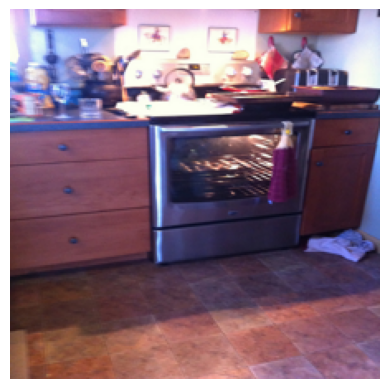

Caption: The image displays a kitchen featuring a stainless steel stove top oven in the center of the room. Around the stovetop, there are several dishes and bowls, some on the countertops, and others on the oven rack. 

Various bottles can be spotted in the scene, possibly indicating that the two glasses present in the foreground might be used to hold beverages or sauces during cooking or when the oven is in use. In addition to the appliances, a clock is visible towards the top-left of the kitchen, keeping track of time as the cook prepares and cooks the various meals.


In [45]:
print("Input Image:")
plt.imshow(image.resize((224, 224)))
plt.axis('off')
plt.show()
print("Caption:", outputs)

### Visualize concepts activated by vision and language representations

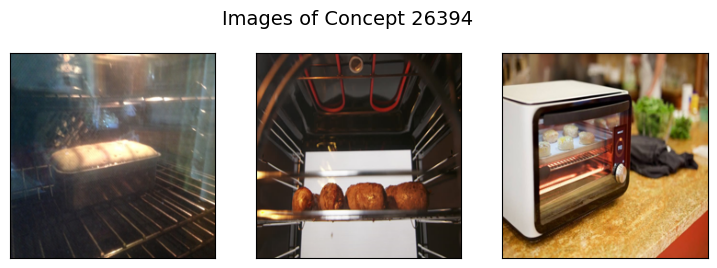

****************************************
Texts of Concept 26394:
Text 0, <image>
cookies about to come out of the oven .
Text 1, <image>
pizza on a special shovel rotate in the oven
Text 2, <image>
an example of a compact pro single deck oven .
****************************************


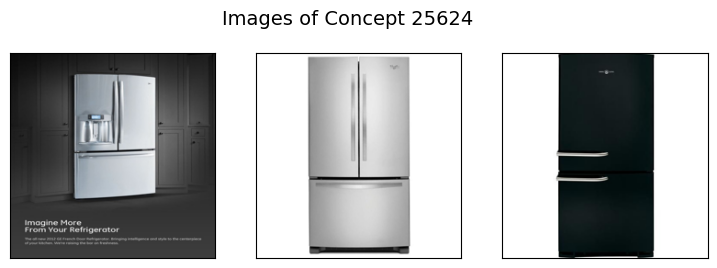

****************************************
Texts of Concept 25624:
Text 0, <image>
what are the benefits of a bottom mount refrigerator ?
Text 1, <image>
white metal shelf in a refrigerator .
Text 2, <image>
interior view of the refrigerator .
****************************************


In [46]:
image_concepts = autoencoder.encode(alignment_model(vision_features=image_features.unsqueeze(0))[0]).detach().cpu()
text_concepts = autoencoder.encode(alignment_model(text_features=text_features.unsqueeze(0))[1]).detach().cpu()

# display only the text
# display_concepts(image_concept * text_concept, concept2data, top_k=2, vis_image=False)

# display image with urls
# warning: some images may not be displaying properly, as many URLs of CC3M dataset have expired.
# display_concepts(image_concept * text_concept, concept2data, top_k=2, vis_image=True)

# display with downloaded dataset (Recommended)
# Users need to prepare the CC3M dataset following the instructions in README
display_concepts(image_concepts * text_concepts, concept2data, image_dir="../../CC3M/cc3m_jpg", top_k=2, vis_image=True)